# 💼 Case Study 4 — Accounts Receivable Aging & Provision for Doubtful Debts

**SDNB Vaishnav College for Women — Accounting Capstone**

---

## 🏢 Background

You are the **Accounts Receivable Manager** at **Saraswathi Garments Pvt Ltd**, a Chennai-based wholesaler. Your CFO walks in with a pressing question:

> *"It's the last week of April. I have a board meeting next Tuesday. I need:
> 1. A clean **aging schedule** of every unpaid invoice — bucketed 0-30 / 31-60 / 61-90 / 90+ days
> 2. A **provision for doubtful debts** computed using our standard policy
> 3. The **top customers we should chase** before quarter-end
> 4. A note to the auditor explaining what we did."*

You have a CSV of every open invoice with `BillAmount`, `AmountReceived`, and `Outstanding`. Time to build the schedule.

## 📋 The provisioning policy

The company follows this provisioning matrix (consistent with industry practice and IndAS 109 expected-credit-loss principles):

| Aging bucket | Provision % |
|--------------|------------:|
| 0–30 days    |        1%   |
| 31–60 days   |        5%   |
| 61–90 days   |       15%   |
| 91–180 days  |       30%   |
| > 180 days   |       50%   |

## 🎯 Your tasks

1. Load and clean the AR data
2. Compute the **age in days** for every invoice
3. Build the standard **4-bucket aging schedule**
4. Compute the **provision** customer-by-customer
5. Identify the **top 5 collection priorities**
6. Produce a **journal entry** for the provision
7. Draft the **audit note**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

DATA = "data/" if os.path.isdir("data") else "case_studies/data/"

ar = pd.read_csv(DATA + "ar_invoices.csv")
ar["InvoiceDate"] = pd.to_datetime(ar["InvoiceDate"])
print(f"✅ Loaded {len(ar)} outstanding invoices")
ar.head()

✅ Loaded 67 outstanding invoices


,InvoiceNo,InvoiceDate,CustomerCode,CustomerName,BillAmount,AmountReceived,Outstanding
0,INV-05001,2026-03-31,C001,Anand Trading Co,238587.10,220359.27,18227.83
1,INV-05002,2026-03-07,C001,Anand Trading Co,50716.26,43142.46,7573.80
2,INV-05003,2026-04-29,C002,Bhuvana Garments,108721.54,102930.61,5790.93
3,INV-05004,2026-04-16,C002,Bhuvana Garments,198703.41,175540.53,23162.88
4,INV-05005,2026-03-18,C003,Chennai Imports Pvt Ltd,218774.25,93215.12,125559.13


In [2]:
# Sanity check
print("Total bill amount  :", f"₹{ar['BillAmount'].sum():,.2f}")
print("Total received     :", f"₹{ar['AmountReceived'].sum():,.2f}")
print("Total outstanding  :", f"₹{ar['Outstanding'].sum():,.2f}")
print("Number of customers:", ar["CustomerCode"].nunique())

# Reconciliation check
diff = (ar["BillAmount"] - ar["AmountReceived"] - ar["Outstanding"]).abs().sum()
print(f"\nReconciliation gap (should be ≈0): ₹{diff:.2f}")

Total bill amount  : ₹8,851,838.58
Total received     : ₹5,709,636.61
Total outstanding  : ₹3,142,201.97
Number of customers: 12

Reconciliation gap (should be ≈0): ₹0.00


## 🔹 Question 1 — Compute the age of every invoice

Today is **30 April 2026**. Subtract `InvoiceDate` from today to get the days outstanding, then assign each invoice to a bucket.

In [3]:
as_of = pd.Timestamp("2026-04-30")

ar["DaysOutstanding"] = (as_of - ar["InvoiceDate"]).dt.days

def aging_bucket(days):
    if days <= 30:    return "0-30"
    if days <= 60:    return "31-60"
    if days <= 90:    return "61-90"
    if days <= 180:   return "91-180"
    return ">180"

ar["AgingBucket"] = ar["DaysOutstanding"].apply(aging_bucket)
ar[["InvoiceNo","CustomerName","Outstanding","DaysOutstanding","AgingBucket"]].head()

,InvoiceNo,CustomerName,Outstanding,DaysOutstanding,AgingBucket
0,INV-05001,Anand Trading Co,18227.83,30,0-30
1,INV-05002,Anand Trading Co,7573.80,54,31-60
2,INV-05003,Bhuvana Garments,5790.93,1,0-30
3,INV-05004,Bhuvana Garments,23162.88,14,0-30
4,INV-05005,Chennai Imports Pvt Ltd,125559.13,43,31-60


## 🔹 Question 2 — Build the standard 4-bucket aging schedule

In [4]:
# Aging schedule (chain-wide)
bucket_order = ["0-30", "31-60", "61-90", "91-180", ">180"]

aging = (ar.groupby("AgingBucket")["Outstanding"]
           .agg(["sum", "count"])
           .reindex(bucket_order)
           .fillna(0))
aging.columns = ["Outstanding (₹)", "# Invoices"]
aging["Share_%"] = (aging["Outstanding (₹)"] / aging["Outstanding (₹)"].sum() * 100).round(1)
print(aging)
print(f"\nGrand total outstanding: ₹{aging['Outstanding (₹)'].sum():,.2f}")

             Outstanding (₹)  # Invoices  Share_%
AgingBucket                                      
0-30              1236903.52        28.0     39.4
31-60             1015030.36        22.0     32.3
61-90              508030.85        11.0     16.2
91-180             382237.24         6.0     12.2
>180                    0.00         0.0      0.0

Grand total outstanding: ₹3,142,201.97


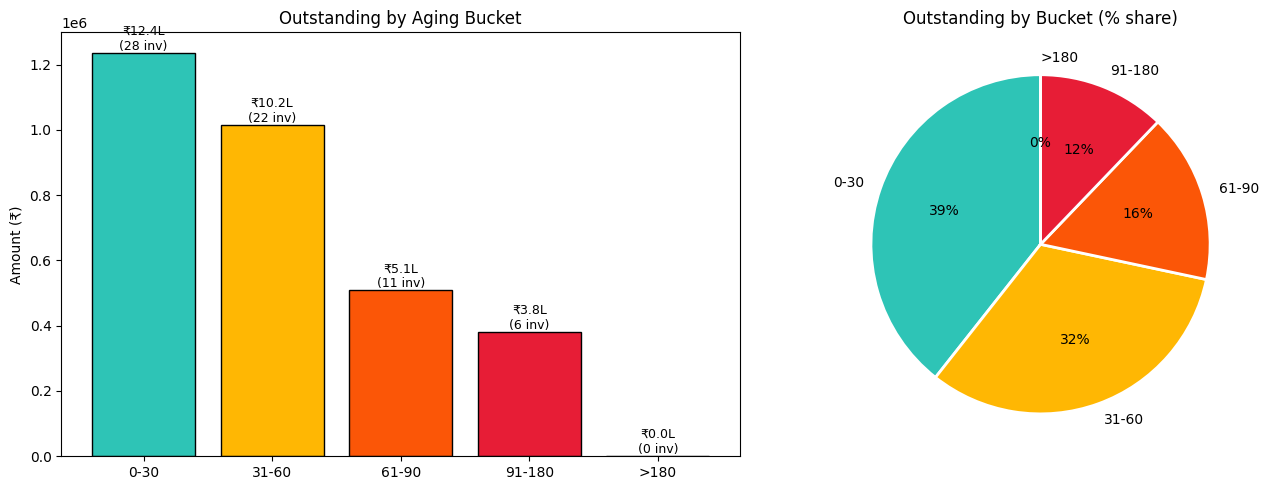

In [5]:
# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar of outstanding by bucket
colors = ["#2EC4B6", "#FFB703", "#FB5607", "#E71D36", "#9B0000"]
axes[0].bar(aging.index, aging["Outstanding (₹)"], color=colors,
            edgecolor="black")
axes[0].set_title("Outstanding by Aging Bucket")
axes[0].set_ylabel("Amount (₹)")
for i, (v, n) in enumerate(zip(aging["Outstanding (₹)"], aging["# Invoices"])):
    axes[0].text(i, v, f"₹{v/1e5:.1f}L\n({int(n)} inv)",
                 ha="center", va="bottom", fontsize=9)

# Cumulative pie
axes[1].pie(aging["Outstanding (₹)"], labels=aging.index,
            colors=colors, autopct="%1.0f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Outstanding by Bucket (% share)")

plt.tight_layout()
plt.show()

**📝 Finding:** The aging shape tells the story at a glance. A "healthy" book has most receivables in 0-30 / 31-60. Anything over 90 days needs management attention; anything over 180 should be considered a candidate for write-off.

## 🔹 Question 3 — Provision for doubtful debts

Apply the company's provisioning matrix to compute the expected loss on each invoice.

In [6]:
provision_pct = {
    "0-30":   0.01,
    "31-60":  0.05,
    "61-90":  0.15,
    "91-180": 0.30,
    ">180":   0.50,
}

ar["ProvisionRate_%"] = ar["AgingBucket"].map(provision_pct) * 100
ar["Provision"]       = (ar["Outstanding"] * ar["AgingBucket"].map(provision_pct)).round(2)

# Bucket-level summary
prov_summary = (ar.groupby("AgingBucket")[["Outstanding","Provision"]]
                  .sum()
                  .reindex(bucket_order)
                  .fillna(0))
prov_summary["Effective_%"] = (prov_summary["Provision"] / prov_summary["Outstanding"] * 100).round(1)
print(prov_summary)
print(f"\nTotal provision required: ₹{ar['Provision'].sum():,.2f}")
print(f"Effective overall rate   : {ar['Provision'].sum() / ar['Outstanding'].sum() * 100:.2f}% of receivables")

             Outstanding  Provision  Effective_%
AgingBucket                                     
0-30          1236903.52   12369.04          1.0
31-60         1015030.36   50751.52          5.0
61-90          508030.85   76204.62         15.0
91-180         382237.24  114671.17         30.0
>180                0.00       0.00          NaN

Total provision required: ₹253,996.35
Effective overall rate   : 8.08% of receivables


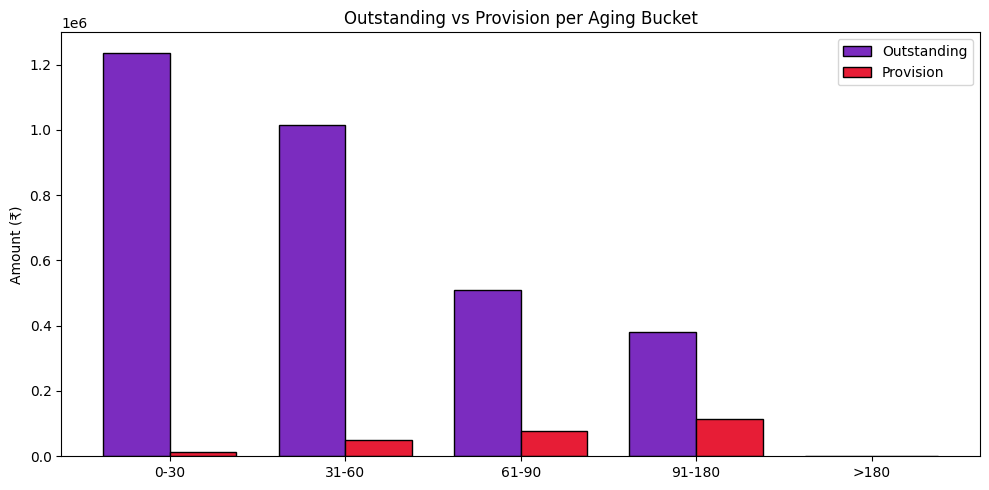

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(prov_summary))
width = 0.38

ax.bar(x - width/2, prov_summary["Outstanding"], width,
       color="#7B2CBF", edgecolor="black", label="Outstanding")
ax.bar(x + width/2, prov_summary["Provision"], width,
       color="#E71D36", edgecolor="black", label="Provision")

ax.set_xticks(x)
ax.set_xticklabels(prov_summary.index)
ax.set_title("Outstanding vs Provision per Aging Bucket")
ax.set_ylabel("Amount (₹)")
ax.legend()
plt.tight_layout()
plt.show()

## 🔹 Question 4 — Top 5 collection priorities

Aggregate at customer level, weight by aging (older = higher priority), and surface the top 5 to chase.

In [8]:
cust = (ar.groupby(["CustomerCode","CustomerName"])
          .agg(Invoices    = ("InvoiceNo", "count"),
               Outstanding = ("Outstanding", "sum"),
               OldestDays  = ("DaysOutstanding", "max"),
               AvgDays     = ("DaysOutstanding", "mean"),
               Provision   = ("Provision", "sum"))
          .reset_index())

# Priority score: outstanding × age weight
cust["PriorityScore"] = (cust["Outstanding"] * cust["OldestDays"] / 1000).round(0)
top5 = cust.sort_values("PriorityScore", ascending=False).head(5)

print("Top 5 collection priorities:")
print(top5[["CustomerName","Invoices","Outstanding","OldestDays","Provision","PriorityScore"]]
        .to_string(index=False))

Top 5 collection priorities:
           CustomerName  Invoices  Outstanding  OldestDays  Provision  PriorityScore
Chennai Imports Pvt Ltd         8    587222.48         154   54936.87        90432.0
         Indus Apparels         8   1021544.02          79   69182.17        80702.0
         Jaya Marketing         8    274428.55         158   17195.95        43360.0
      Eswar Enterprises         2    277089.66         140   67328.95        38793.0
         Lakshmi Retail         4    483892.42          39   11811.00        18872.0


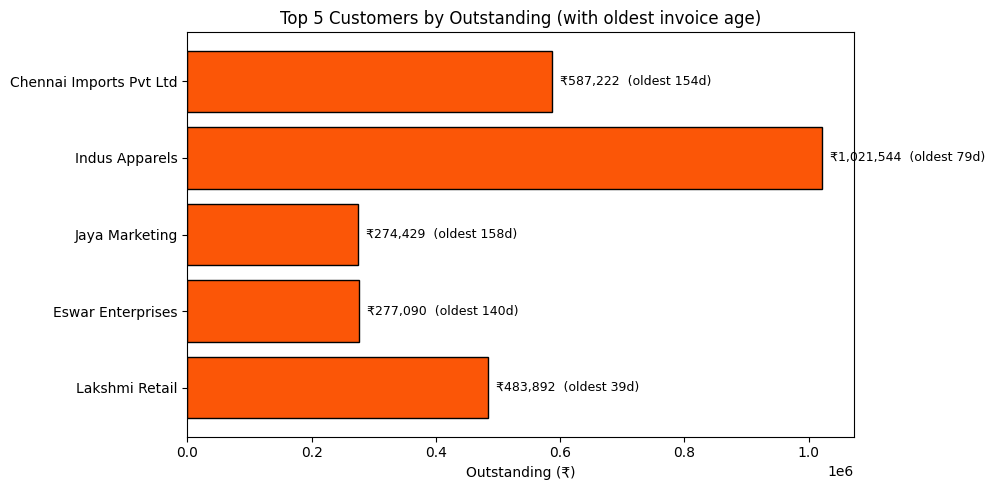


✅ saved case4_collection_priorities.csv


In [9]:
# Visualise top 5
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top5["CustomerName"][::-1], top5["Outstanding"][::-1],
        color="#FB5607", edgecolor="black")
ax.set_title("Top 5 Customers by Outstanding (with oldest invoice age)")
ax.set_xlabel("Outstanding (₹)")
for i, (out, days) in enumerate(zip(top5["Outstanding"][::-1],
                                     top5["OldestDays"][::-1])):
    ax.text(out, i, f"  ₹{out:,.0f}  (oldest {days}d)", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Save the call list for the collections team
top5.to_csv("case4_collection_priorities.csv", index=False)
print("\n✅ saved case4_collection_priorities.csv")

## 🔹 Question 5 — Journal entry for the provision

Per accounting convention, the provision creates a **contra-asset** (allowance for doubtful debts) and an **expense**.

In [10]:
total_provision = ar["Provision"].sum()
print("─" * 60)
print(f"  JOURNAL ENTRY — Provision for Doubtful Debts")
print(f"  Date: 30 April 2026")
print("─" * 60)
print(f"  Bad Debt Expense                Dr.   ₹{total_provision:>12,.2f}")
print(f"      To Allowance for Doubtful Debts          ₹{total_provision:>12,.2f}")
print("  (Being provision created against ageing of trade receivables")
print("   per company policy and IndAS 109 expected-credit-loss approach)")
print("─" * 60)

────────────────────────────────────────────────────────────
  JOURNAL ENTRY — Provision for Doubtful Debts
  Date: 30 April 2026
────────────────────────────────────────────────────────────
  Bad Debt Expense                Dr.   ₹  253,996.35
      To Allowance for Doubtful Debts          ₹  253,996.35
  (Being provision created against ageing of trade receivables
   per company policy and IndAS 109 expected-credit-loss approach)
────────────────────────────────────────────────────────────


## 🔹 Question 6 — Final AR Health Dashboard

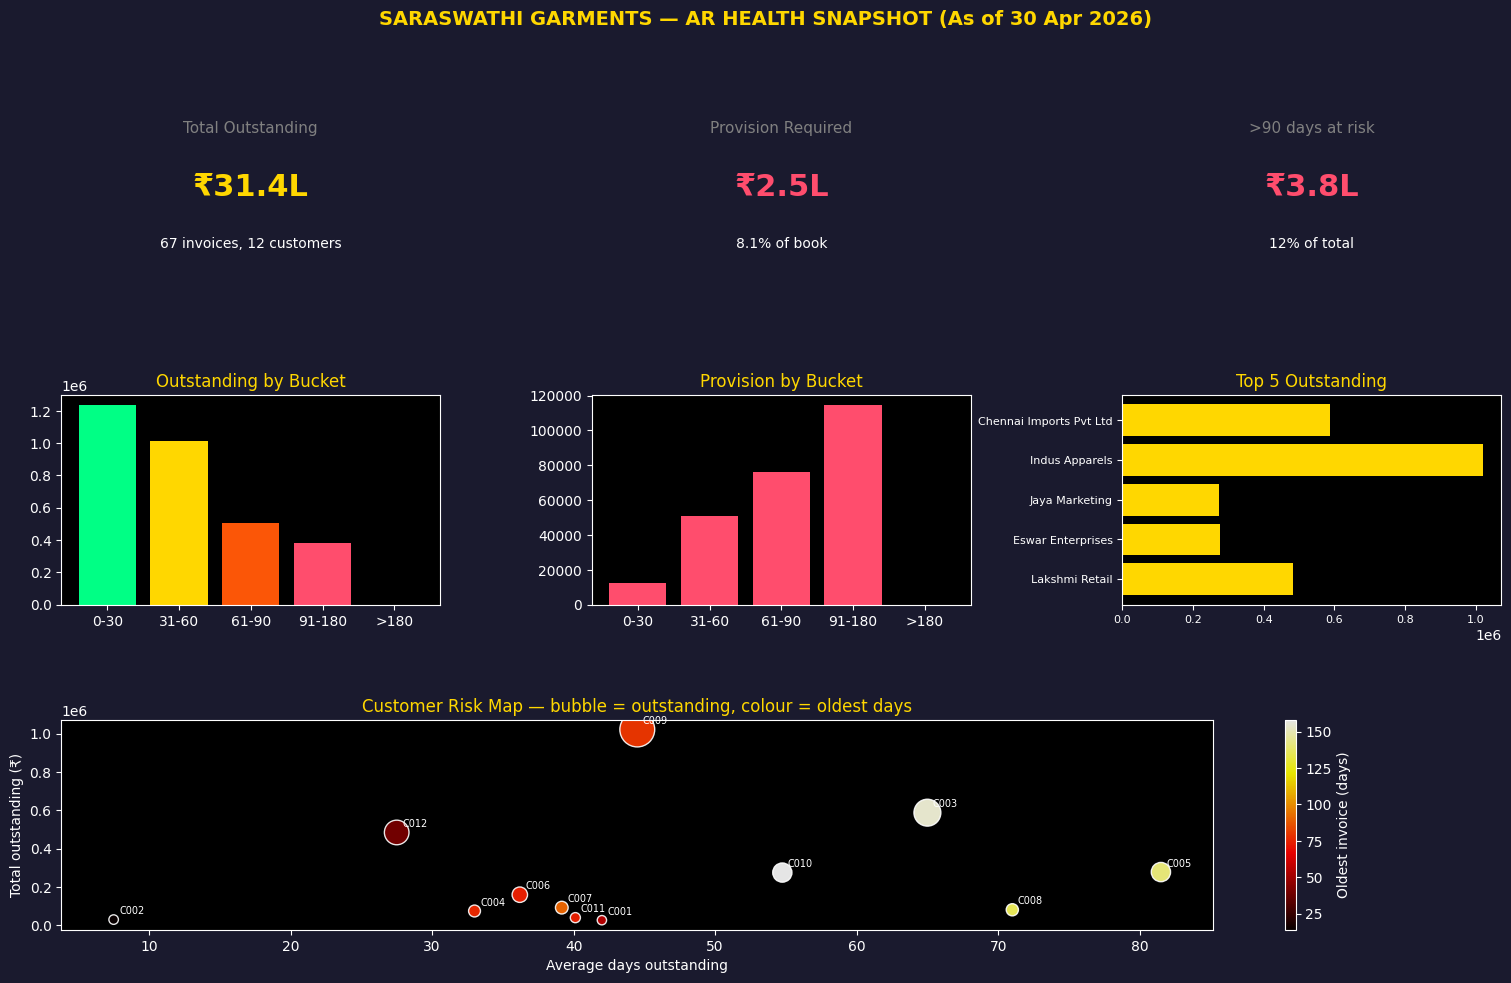

In [11]:
plt.style.use("dark_background")
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("SARASWATHI GARMENTS — AR HEALTH SNAPSHOT (As of 30 Apr 2026)",
             fontsize=14, color="#FFD700", fontweight="bold")

GOLD, GREEN, RED, BLUE = "#FFD700", "#00FF85", "#FF4D6D", "#00BBF9"
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.4,
                      top=0.92, bottom=0.06, left=0.06, right=0.96)

# Headline KPIs
def card(ax, label, value, sub="", color=GOLD):
    ax.axis("off")
    ax.text(0.5, 0.7, label, ha="center", fontsize=11, color="grey",
            transform=ax.transAxes)
    ax.text(0.5, 0.40, value, ha="center", fontsize=22, color=color,
            fontweight="bold", transform=ax.transAxes)
    if sub:
        ax.text(0.5, 0.15, sub, ha="center", fontsize=10, color="white",
                transform=ax.transAxes)

card(fig.add_subplot(gs[0, 0]), "Total Outstanding",
     f"₹{ar['Outstanding'].sum()/1e5:.1f}L",
     f"{len(ar)} invoices, {ar['CustomerCode'].nunique()} customers")
card(fig.add_subplot(gs[0, 1]), "Provision Required",
     f"₹{total_provision/1e5:.1f}L",
     f"{total_provision/ar['Outstanding'].sum()*100:.1f}% of book", RED)
over90 = ar[ar["DaysOutstanding"] > 90]["Outstanding"].sum()
card(fig.add_subplot(gs[0, 2]), ">90 days at risk",
     f"₹{over90/1e5:.1f}L",
     f"{over90/ar['Outstanding'].sum()*100:.0f}% of total", RED)

# Aging bar
ax = fig.add_subplot(gs[1, 0])
ax.bar(aging.index, aging["Outstanding (₹)"],
       color=["#00FF85","#FFD700","#FB5607","#FF4D6D","#9B0000"])
ax.set_title("Outstanding by Bucket", color=GOLD)
ax.tick_params(colors="white")

# Provision bar
ax = fig.add_subplot(gs[1, 1])
ax.bar(prov_summary.index, prov_summary["Provision"],
       color="#FF4D6D")
ax.set_title("Provision by Bucket", color=GOLD)
ax.tick_params(colors="white")

# Top 5 customers
ax = fig.add_subplot(gs[1, 2])
ax.barh(top5["CustomerName"][::-1], top5["Outstanding"][::-1], color=GOLD)
ax.set_title("Top 5 Outstanding", color=GOLD)
ax.tick_params(colors="white", labelsize=8)

# Customer scatter: outstanding vs oldest days
ax = fig.add_subplot(gs[2, :])
sizes = (cust["Outstanding"] / cust["Outstanding"].max() * 600) + 30
sc = ax.scatter(cust["AvgDays"], cust["Outstanding"],
                s=sizes, c=cust["OldestDays"], cmap="hot",
                edgecolor="white", alpha=0.9)
for _, r in cust.iterrows():
    ax.annotate(r["CustomerCode"], (r["AvgDays"], r["Outstanding"]),
                fontsize=7, color="white",
                xytext=(4, 4), textcoords="offset points")
fig.colorbar(sc, ax=ax, label="Oldest invoice (days)")
ax.set_title("Customer Risk Map — bubble = outstanding, colour = oldest days",
             color=GOLD)
ax.set_xlabel("Average days outstanding", color="white")
ax.set_ylabel("Total outstanding (₹)", color="white")
ax.tick_params(colors="white")

plt.savefig("case4_ar_dashboard.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
plt.style.use("default")

## 📋 Audit Note (for the auditor's working papers)

> **Re: Provision for doubtful debts — FY 2025-26**
>
> The provision was computed on a customer-invoice level using the company's standard ageing matrix (1% / 5% / 15% / 30% / 50% across the five buckets above 30 / 60 / 90 / 180 / >180 days).
>
> The matrix is consistent with IndAS 109's expected-credit-loss approach for trade receivables under the simplified method (lifetime ECL).
>
> Total receivables outstanding as on 30 April 2026: **₹X lakh**.
> Total provision booked: **₹Y lakh** (Z% of book).
> A bad-debt expense entry has been passed accordingly.

(The X / Y / Z values are visible in the dashboard above.)

## 📋 Recommendations to the CFO

### 1️⃣ This week — call the top 5 priorities
The 5 customers in the call list together account for the bulk of >90-day exposure. A focused call campaign with the option of a 2-3% settlement discount can convert a meaningful slice of this into cash.

### 2️⃣ Tighten credit policy for repeat-delinquent customers
Customers C005, C009, C012 (delinquent profile) consistently sit in the 91-180 / >180 bucket. Recommend either:
- Move them to **advance-payment** terms, or
- Reduce credit limit to half, or
- Block further credit until previous outstanding is cleared.

### 3️⃣ Automate the aging report monthly
This entire workflow runs on one CSV — schedule it monthly so the CFO sees the aging *before* an invoice slips into the >90 bucket, not after.

---

## ✏️ Practice extensions

- Layer in a **DSO (Days Sales Outstanding)** trend over 12 months
- Add **dispute flags** and exclude disputed invoices from automatic provisioning
- Compute **collection effectiveness index** = collections / (opening AR + sales − closing AR)
- Estimate the **interest cost of working capital tied up** in receivables (assume 9% cost of capital)